In [1]:
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score, log_loss,
    f1_score, precision_score, recall_score,
    precision_recall_curve, roc_curve, confusion_matrix,
)

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

TRAIN_PATH = "../../datasets/dataset (tasks 2 and 3)/train.csv"
TEST_PATH = "../../datasets/dataset (tasks 2 and 3)/test.csv"

In [3]:
BATCH_SIZE = 512  # rows per gradient step
MAX_EPOCHS = 30  # max passes over the training data
PATIENCE = 5  # stop if val AUC has not improved for this many epochs
LR = 1e-3  # Adam learning rate
EMB_DIM = 16  # length of the learned vector for every category
MIN_COUNT = 5  # categories seen < 5 times in train share the "unknown" id 0

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cpu


In [4]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

In [5]:
num_cols = [f"integer_feature_{i}" for i in range(1, 14)]
cat_cols = [f"categorical_feature_{i}" for i in range(1, 27)]

print("Train:", train.shape, "| Test:", test.shape)
print("Click rate:", round(train["label"].mean(), 4))
print("Missing values in train features:", int(train[num_cols + cat_cols].isna().sum().sum()))

X = train[num_cols + cat_cols]
y = train["label"].astype(int).to_numpy()

X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y  # stratify keeps the click rate equal
)
print("Train rows:", len(X_tr), "| Validation rows:", len(X_val))

Train: (40000, 40) | Test: (10000, 40)
Click rate: 0.032
Missing values in train features: 153603
Train rows: 32000 | Validation rows: 8000


In [6]:
# --- Numeric: median fill, then standardize  x' = (x - mean) / std
# Both are FITTED ON TRAIN ONLY, then applied to validation/test (no leakage).
imputer = SimpleImputer(strategy="median").fit(X_tr[num_cols])
scaler = StandardScaler().fit(imputer.transform(X_tr[num_cols]))


def encode_numeric(df):
    filled = imputer.transform(df[num_cols])
    return scaler.transform(filled).astype(np.float32)

In [7]:
# --- Categorical: turn each value into an integer id.
# Missing becomes its own category "MISSING". Values seen at least MIN_COUNT times
# in TRAIN get ids 1, 2, 3, ...  Everything else (rare or never seen) gets id 0.
vocab = {}
for col in cat_cols:
    counts = X_tr[col].fillna("MISSING").astype(str).value_counts()
    kept = counts[counts >= MIN_COUNT].index
    vocab[col] = {category: i + 1 for i, category in enumerate(kept)}


def encode_categorical(df):
    out = np.zeros((len(df), len(cat_cols)), dtype=np.int64)
    for j, col in enumerate(cat_cols):
        values = df[col].fillna("MISSING").astype(str)
        out[:, j] = values.map(vocab[col]).fillna(0).astype(np.int64)
    return out


vocab_sizes = [len(vocab[col]) + 1 for col in cat_cols]  # +1 for the id-0 "unknown" slot

num_tr, cat_tr = encode_numeric(X_tr), encode_categorical(X_tr)
num_val, cat_val = encode_numeric(X_val), encode_categorical(X_val)
print("Numeric shape:", num_tr.shape, "| Categorical shape:", cat_tr.shape)
print("Largest vocabulary:", max(vocab_sizes), "| Smallest:", min(vocab_sizes))


Numeric shape: (32000, 13) | Categorical shape: (32000, 26)
Largest vocabulary: 1290 | Smallest: 3


In [8]:
# --- Mini-batch loaders
def make_loader(num, cat, labels=None, shuffle=False):
    tensors = [torch.tensor(num), torch.tensor(cat)]
    if labels is not None:
        tensors.append(torch.tensor(labels, dtype=torch.float32))
    return DataLoader(TensorDataset(*tensors), batch_size=BATCH_SIZE, shuffle=shuffle)


train_loader = make_loader(num_tr, cat_tr, y_tr, shuffle=True)
val_loader = make_loader(num_val, cat_val, y_val)

In [9]:
class CTRNet(nn.Module):
    """
    category ids --(embedding tables)--> vectors \
                                                  >-- concat --> hidden layers --> 1 number (logit)
    numeric features (standardized) ------------ /
    probability of click = sigmoid(logit)
    """

    def __init__(self, n_numeric, vocab_sizes, hidden_dims, dropout):
        super().__init__()
        # one lookup table (vocab_size x EMB_DIM) per categorical column
        self.embeddings = nn.ModuleList([nn.Embedding(v, EMB_DIM) for v in vocab_sizes])

        in_dim = n_numeric + EMB_DIM * len(vocab_sizes)
        layers = []
        for h in hidden_dims:
            layers += [nn.Linear(in_dim, h), nn.ReLU(), nn.Dropout(dropout)]
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))  # last layer = logistic regression on learned features
        self.mlp = nn.Sequential(*layers)

    def forward(self, num, cat):
        looked_up = [table(cat[:, j]) for j, table in enumerate(self.embeddings)]
        x = torch.cat([num] + looked_up, dim=1)  # (batch, 13 + 26*EMB_DIM)
        return self.mlp(x).squeeze(1)  # (batch,) of logits

In [10]:
def predict(model, loader):
    """Return click probabilities for every row in the loader (dropout OFF)."""
    model.eval()
    probs = []
    with torch.no_grad():
        for batch in loader:
            num, cat = batch[0].to(DEVICE), batch[1].to(DEVICE)
            probs.append(torch.sigmoid(model(num, cat)).cpu().numpy())
    return np.concatenate(probs).astype(np.float64)

In [11]:

def train_model(hidden_dims, dropout):
    model = CTRNet(len(num_cols), vocab_sizes, hidden_dims, dropout).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    loss_fn = nn.BCEWithLogitsLoss()  # = log loss, with the sigmoid built in

    history = {"train_loss": [], "val_loss": [], "val_auc": []}
    best_auc, best_epoch, best_state, bad_epochs = -1.0, 0, None, 0

    for epoch in range(1, MAX_EPOCHS + 1):
        # ---- one pass over the training data (dropout ON)
        model.train()
        total, n = 0.0, 0
        for num, cat, labels in train_loader:
            num, cat, labels = num.to(DEVICE), cat.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()  # 1. clear old gradients
            loss = loss_fn(model(num, cat), labels)  # 2. forward pass + loss
            loss.backward()  # 3. backpropagation: gradient of loss for every weight
            optimizer.step()  # 4. Adam update of every weight
            total += loss.item() * len(labels)
            n += len(labels)

        # ---- score the validation set (dropout OFF)
        val_probs = predict(model, val_loader)
        train_loss = total / n
        val_loss = log_loss(y_val, val_probs)
        val_auc = roc_auc_score(y_val, val_probs)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_auc"].append(val_auc)
        print(f"Epoch {epoch:02d} | train loss {train_loss:.4f} | "
              f"val loss {val_loss:.4f} | val AUC {val_auc:.4f}")

        # ---- early stopping: remember the best epoch, quit after PATIENCE bad ones
        if val_auc > best_auc:
            best_auc, best_epoch, bad_epochs = val_auc, epoch, 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            bad_epochs += 1
            if bad_epochs >= PATIENCE:
                print("Early stopping.")
                break

    model.load_state_dict(best_state)  # go back to the best epoch's weights
    return model, history, best_auc, best_epoch

In [12]:



architectures = [
    {"name": "Small", "hidden_dims": (64,), "dropout": 0.1},
    {"name": "Medium", "hidden_dims": (128, 64), "dropout": 0.2},
    {"name": "Large", "hidden_dims": (256, 128, 64), "dropout": 0.3},
]

models, histories, rows = {}, {}, []
for cfg in architectures:
    print("\n" + "=" * 60 + f"\nTraining {cfg['name']} {cfg['hidden_dims']} dropout={cfg['dropout']}")
    model, history, best_auc, best_epoch = train_model(cfg["hidden_dims"], cfg["dropout"])
    models[cfg["name"]], histories[cfg["name"]] = model, history
    rows.append({
        "Architecture": cfg["name"],
        "Hidden layers": str(cfg["hidden_dims"]),
        "Dropout": cfg["dropout"],
        "Best epoch": best_epoch,
        "Train loss @best": history["train_loss"][best_epoch - 1],
        "Val loss @best": history["val_loss"][best_epoch - 1],
        "Best val ROC-AUC": best_auc,
    })

comparison = pd.DataFrame(rows).sort_values("Best val ROC-AUC", ascending=False)
print("\n", comparison.round(4).to_string(index=False))

best_name = comparison.iloc[0]["Architecture"]
best_model = models[best_name]
print("Selected architecture (by validation ROC-AUC):", best_name)


Training Small (64,) dropout=0.1
Epoch 01 | train loss 0.1692 | val loss 0.1381 | val AUC 0.6407
Epoch 02 | train loss 0.1379 | val loss 0.1335 | val AUC 0.6949
Epoch 03 | train loss 0.1341 | val loss 0.1328 | val AUC 0.7022
Epoch 04 | train loss 0.1315 | val loss 0.1326 | val AUC 0.7049
Epoch 05 | train loss 0.1284 | val loss 0.1328 | val AUC 0.7064
Epoch 06 | train loss 0.1250 | val loss 0.1346 | val AUC 0.6972
Epoch 07 | train loss 0.1214 | val loss 0.1361 | val AUC 0.6934
Epoch 08 | train loss 0.1183 | val loss 0.1374 | val AUC 0.6916
Epoch 09 | train loss 0.1144 | val loss 0.1405 | val AUC 0.6830
Epoch 10 | train loss 0.1104 | val loss 0.1434 | val AUC 0.6784
Early stopping.

Training Medium (128, 64) dropout=0.2
Epoch 01 | train loss 0.1836 | val loss 0.1379 | val AUC 0.6460
Epoch 02 | train loss 0.1400 | val loss 0.1340 | val AUC 0.6945
Epoch 03 | train loss 0.1346 | val loss 0.1337 | val AUC 0.6947
Epoch 04 | train loss 0.1302 | val loss 0.1352 | val AUC 0.6942
Epoch 05 | trai

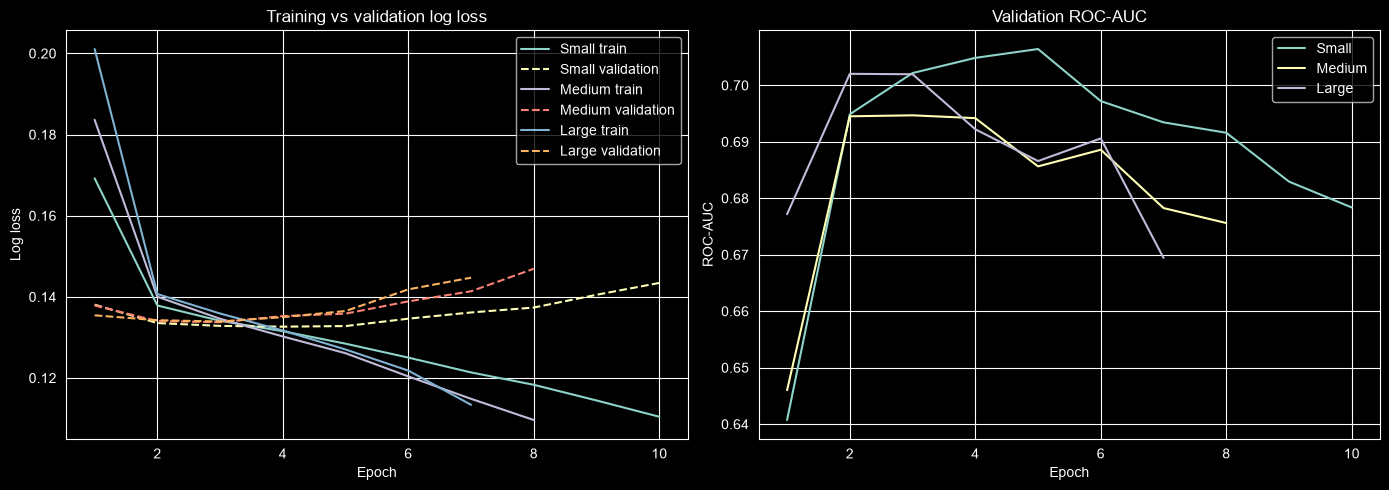

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, h in histories.items():
    epochs = range(1, len(h["train_loss"]) + 1)
    axes[0].plot(epochs, h["train_loss"], label=f"{name} train")
    axes[0].plot(epochs, h["val_loss"], "--", label=f"{name} validation")
    axes[1].plot(epochs, h["val_auc"], label=name)
axes[0].set(title="Training vs validation log loss", xlabel="Epoch", ylabel="Log loss")
axes[1].set(title="Validation ROC-AUC", xlabel="Epoch", ylabel="ROC-AUC")
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()

In [14]:
val_probs = predict(best_model, val_loader)

prec, rec, thr = precision_recall_curve(y_val, val_probs)
f1 = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)  # [:-1]: thr has one fewer entry
best_threshold = thr[np.argmax(f1)]
print(f"Threshold = {best_threshold:.4f}  (validation F1 = {f1.max():.4f})")


def evaluate(y_true, probs, threshold):
    pred = (probs >= threshold).astype(int)
    return {
        "ROC-AUC": roc_auc_score(y_true, probs),
        "PR-AUC": average_precision_score(y_true, probs),
        "Log loss": log_loss(y_true, probs),
        "Accuracy": accuracy_score(y_true, pred),
        "F1": f1_score(y_true, pred, zero_division=0),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "Recall": recall_score(y_true, pred, zero_division=0),
    }


val_metrics = evaluate(y_val, val_probs, best_threshold)
print(pd.Series(val_metrics, name=f"{best_name} (validation)").round(4).to_string())

cm = confusion_matrix(y_val, (val_probs >= best_threshold).astype(int), labels=[0, 1])
print("\nConfusion matrix at the chosen threshold:")
print(pd.DataFrame(cm, index=["actual no click", "actual click"],
                   columns=["pred no click", "pred click"]))

fpr, tpr, _ = roc_curve(y_val, val_probs)
frac_clicked, mean_pred = calibration_curve(y_val, val_probs, n_bins=10, strategy="quantile")

Threshold = 0.0600  (validation F1 = 0.1478)
ROC-AUC      0.7064
PR-AUC       0.0873
Log loss     0.1328
Accuracy     0.8559
F1           0.1478
Precision    0.0912
Recall       0.3906

Confusion matrix at the chosen threshold:
                 pred no click  pred click
actual no click           6747         997
actual click               156         100


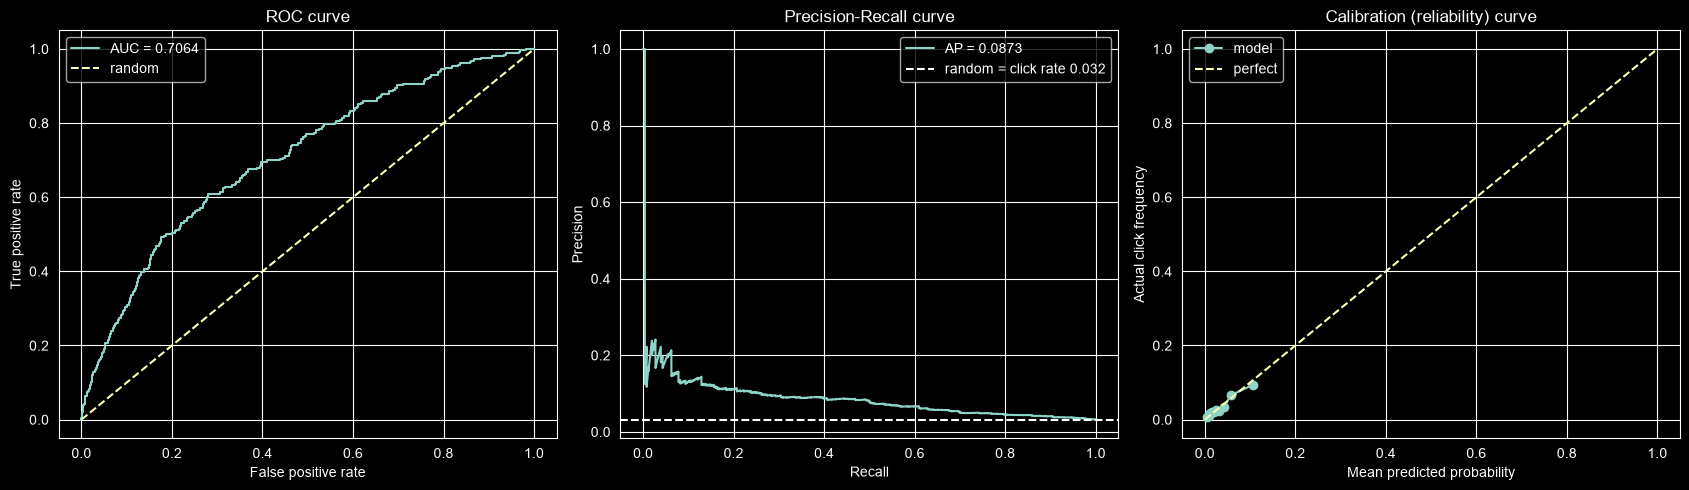

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].plot(fpr, tpr, label=f"AUC = {val_metrics['ROC-AUC']:.4f}")
axes[0].plot([0, 1], [0, 1], "--", label="random")
axes[0].set(title="ROC curve", xlabel="False positive rate", ylabel="True positive rate")
axes[0].legend()

axes[1].plot(rec, prec, label=f"AP = {val_metrics['PR-AUC']:.4f}")
axes[1].axhline(y_val.mean(), linestyle="--", label=f"random = click rate {y_val.mean():.3f}")
axes[1].set(title="Precision-Recall curve", xlabel="Recall", ylabel="Precision")
axes[1].legend()

axes[2].plot(mean_pred, frac_clicked, "o-", label="model")
axes[2].plot([0, 1], [0, 1], "--", label="perfect")
axes[2].set(title="Calibration (reliability) curve",
            xlabel="Mean predicted probability", ylabel="Actual click frequency")
axes[2].legend()

plt.tight_layout()
plt.show()

In [16]:
test_loader = make_loader(encode_numeric(test), encode_categorical(test))
test_probs = predict(best_model, test_loader)

if "label" in test.columns:
    y_test = test["label"].astype(int).to_numpy()
    test_metrics = evaluate(y_test, test_probs, best_threshold)
    final = pd.DataFrame({"Validation": val_metrics, "Test": test_metrics})
    print("Final metrics (threshold chosen on validation):")
    print(final.round(4).to_string())
else:
    pd.DataFrame({"click_probability": test_probs}).to_csv("ctr_test_predictions.csv", index=False)
    print("Test has no label column. Saved predictions to ctr_test_predictions.csv")

Final metrics (threshold chosen on validation):
           Validation    Test
ROC-AUC        0.7064  0.6895
PR-AUC         0.0873  0.0700
Log loss       0.1328  0.1400
Accuracy       0.8559  0.8528
F1             0.1478  0.1280
Precision      0.0912  0.0798
Recall         0.3906  0.3224
